Running Seed 0...
Running Seed 1...
Running Seed 2...
Running Seed 3...
Running Seed 4...
Running Seed 5...
Running Seed 6...
Running Seed 7...
Running Seed 8...
Running Seed 9...
Running Seed 10...
Running Seed 11...
Running Seed 12...
Running Seed 13...
Running Seed 14...
Running Seed 15...
Running Seed 16...
Running Seed 17...
Running Seed 18...
Running Seed 19...
Running Seed 20...
Running Seed 21...
Running Seed 22...
Running Seed 23...
Running Seed 24...
Running Seed 25...
Running Seed 26...
Running Seed 27...
Running Seed 28...
Running Seed 29...
Running Seed 30...
Running Seed 31...
Running Seed 32...
Running Seed 33...
Running Seed 34...
Running Seed 35...
Running Seed 36...
Running Seed 37...
Running Seed 38...
Running Seed 39...
Running Seed 40...
Running Seed 41...
Running Seed 42...
Running Seed 43...
Running Seed 44...
Running Seed 45...
Running Seed 46...
Running Seed 47...
Running Seed 48...
Running Seed 49...
Running Seed 50...
Running Seed 51...
Running Seed 52...
Run

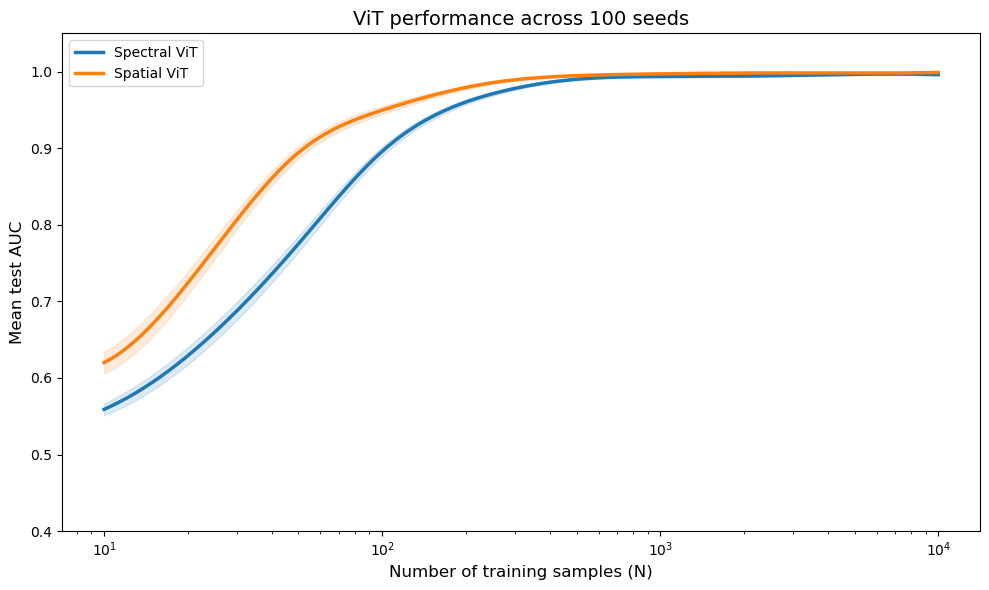

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.interpolate import make_interp_spline
from util import seed_everything

# Configuration
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
N_COMPONENTS = 16 
N_SEEDS = 100
SIZES = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]

# Checkerboard
def generate_checkerboard_data(n_samples, img_size=28, noise_level=1.5):
    images, labels = [], []
    for _ in range(n_samples):
        label = np.random.randint(0, 2)
        noise = np.random.normal(0, noise_level, img_size * img_size)
        if label == 1:
            b_size = np.random.randint(3, 6)
            pad = 8
            large_size = img_size + pad
            base = np.indices((large_size // b_size + 1, large_size // b_size + 1)).sum(axis=0) % 2
            checker = base.repeat(b_size, axis=0).repeat(b_size, axis=1)
            y_off, x_off = np.random.randint(0, pad), np.random.randint(0, pad)
            checker = checker[y_off:y_off+img_size, x_off:x_off+img_size]
            checker = (checker.astype(float) * 2) - 1
            mask = np.random.binomial(1, 0.8, size=(img_size, img_size))
            img = noise + (1.0 * (checker * mask).flatten()) 
        else:
            img = noise
        images.append(img); labels.append(label)
    return np.array(images), np.array(labels)

# Models
class SpectralViT(nn.Module):
    def __init__(self, n_inputs, embed_dim=16):
        super().__init__()
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.register_buffer('rank_weights', 1.0 / ranks)
        self.input_proj = nn.Linear(1, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, n_inputs, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=2, dim_feedforward=32, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=2)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        if x.dim() == 1: x = x.unsqueeze(0)
        x = x * self.rank_weights
        x = self.input_proj(x.unsqueeze(-1)) + self.pos_embed[:, :x.size(1), :] 
        return torch.sigmoid(self.fc(self.transformer(x.transpose(0, 1)).mean(dim=0)).squeeze())
    
class SpatialViT(nn.Module):
    def __init__(self, img_size=28, patch_size=4, embed_dim=16):
        super().__init__()
        self.patch_size, self.n_patches = patch_size, (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=2, dim_feedforward=32, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=2)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        b = x.shape[0]
        x = x.view(b, 1, 28, 28)
        p = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        p = p.contiguous().view(b, self.n_patches, -1)
        x = self.transformer((self.proj(p) + self.pos_embed).transpose(0, 1)).mean(dim=0)
        return torch.sigmoid(self.fc(x).squeeze())

# Execution
all_spectral_results = np.zeros((N_SEEDS, len(SIZES)))
all_spatial_results = np.zeros((N_SEEDS, len(SIZES)))

for seed_idx in range(N_SEEDS):
    seed_everything(seed_idx)
    print(f"Running Seed {seed_idx}...")
    for size_idx, n_samples in enumerate(SIZES):
        X_tr_raw, y_tr = generate_checkerboard_data(n_samples)
        X_te_raw, y_te = generate_checkerboard_data(500)
        scaler = StandardScaler().fit(X_tr_raw)
        X_tr_s, X_te_s = scaler.transform(X_tr_raw), scaler.transform(X_te_raw)
        pca = PCA(n_components=min(n_samples-1, N_COMPONENTS), whiten=True).fit(X_tr_s)
        
        y_tensor = torch.tensor(y_tr, dtype=torch.float32).to(device)
        m_spec, m_spat = SpectralViT(pca.n_components_).to(device), SpatialViT().to(device)
        opt_spec, opt_spat = optim.Adam(m_spec.parameters(), lr=1e-3), optim.Adam(m_spat.parameters(), lr=1e-3)
        
        xt_spec = torch.tensor(pca.transform(X_tr_s), dtype=torch.float32).to(device)
        xt_spat = torch.tensor(X_tr_s, dtype=torch.float32).to(device)
        
        for _ in range(100):
            F.binary_cross_entropy(m_spec(xt_spec), y_tensor).backward(); opt_spec.step(); opt_spec.zero_grad()
            F.binary_cross_entropy(m_spat(xt_spat), y_tensor).backward(); opt_spat.step(); opt_spat.zero_grad()
        
        with torch.no_grad():
            all_spectral_results[seed_idx, size_idx] = roc_auc_score(y_te, m_spec(torch.tensor(pca.transform(X_te_s), dtype=torch.float32).to(device)).cpu().numpy())
            all_spatial_results[seed_idx, size_idx] = roc_auc_score(y_te, m_spat(torch.tensor(X_te_s, dtype=torch.float32).to(device)).cpu().numpy())

# Log plotter
def smooth_curve(x, y):
    x_log = np.log10(x)
    x_new_log = np.linspace(x_log.min(), x_log.max(), 300)
    spline = make_interp_spline(x_log, y, k=3) 
    return 10**x_new_log, spline(x_new_log)

mean_spectral = np.mean(all_spectral_results, axis=0)
ci_spectral = 1.96 * (np.std(all_spectral_results, axis=0) / np.sqrt(N_SEEDS))

mean_spatial = np.mean(all_spatial_results, axis=0)
ci_spatial = 1.96 * (np.std(all_spatial_results, axis=0) / np.sqrt(N_SEEDS))

plt.figure(figsize=(10, 6))

# Spectral
x_smooth, y_smooth_spec = smooth_curve(SIZES, mean_spectral)
_, ci_smooth_spec = smooth_curve(SIZES, ci_spectral)
plt.plot(x_smooth, y_smooth_spec, label='Spectral ViT', color='tab:blue', lw=2.5)
plt.fill_between(x_smooth, y_smooth_spec - ci_smooth_spec, y_smooth_spec + ci_smooth_spec, color='tab:blue', alpha=0.15)

# Spatial
x_smooth, y_smooth_spat = smooth_curve(SIZES, mean_spatial)
_, ci_smooth_spat = smooth_curve(SIZES, ci_spatial)
plt.plot(x_smooth, y_smooth_spat, label='Spatial ViT', color='tab:orange', lw=2.5)
plt.fill_between(x_smooth, y_smooth_spat - ci_smooth_spat, y_smooth_spat + ci_smooth_spat, color='tab:orange', alpha=0.15)


# Intersection
diff = y_smooth_spec - y_smooth_spat
idx_inter = np.where(np.diff(np.sign(diff)))[0]

if len(idx_inter) > 0:
    # Use the first intersection point found
    crossover_n = x_smooth[idx_inter[0]]
    plt.axvline(x=crossover_n, color='black', linestyle='--', alpha=0.7)
    
    # Optional: Add a text annotation for the crossover point
    print(f'N ≈ {int(crossover_n)}')

# Formatting
plt.xscale('log')
plt.xlabel('Number of training samples (N)', fontsize=12)
plt.ylabel('Mean test AUC', fontsize=12)
plt.title(f'ViT performance across {N_SEEDS} seeds', fontsize=14)
plt.legend(frameon=True)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

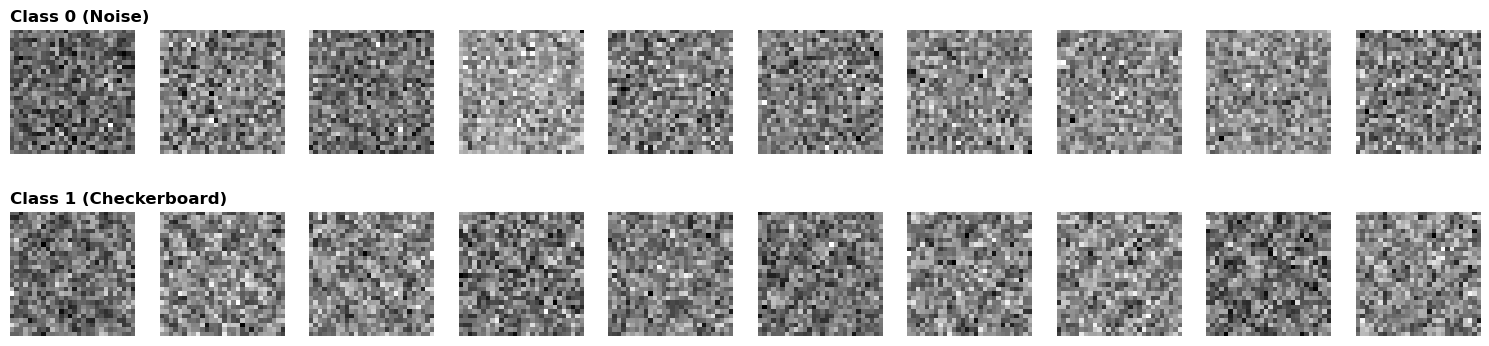

In [2]:
def visualize_samples(n_samples_per_class=10, img_size=28):
    # Generate a pool of samples
    # We generate more than needed to ensure we can pick exactly 10 of each
    X_raw, y_raw = generate_checkerboard_data(n_samples=100)
    
    # Filter classes
    class_0_idx = np.where(y_raw == 0)[0][:n_samples_per_class]
    class_1_idx = np.where(y_raw == 1)[0][:n_samples_per_class]
    
    fig, axes = plt.subplots(2, n_samples_per_class, figsize=(15, 4))
    
    for i in range(n_samples_per_class):
        # Row 0: Class 0 (Pure Noise)
        img0 = X_raw[class_0_idx[i]].reshape(img_size, img_size)
        axes[0, i].imshow(img0, cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title("Class 0 (Noise)", loc='left', fontweight='bold')
            
        # Row 1: Class 1 (Checkerboard + Noise)
        img1 = X_raw[class_1_idx[i]].reshape(img_size, img_size)
        axes[1, i].imshow(img1, cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title("Class 1 (Checkerboard)", loc='left', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Call the function
visualize_samples()